# Raspberry Pi-powered imaging for plant phenotyping — PlantCV segmentation example

**Paper:** Feldman et al., *"Raspberry Pi-powered imaging for plant phenotyping"*, Applications in Plant Sciences 6(3):e1031, 2018. doi:[10.1002/aps3.1031](https://doi.org/10.1002/aps3.1031) (CC BY; PMC5895192)

**Author code:** `danforthcenter/apps-phenotyping` @ commit `698942d476692236f25b1e57784b8e18cf710887` (MIT), Appendix 2 notebooks `time-lapse_split.ipynb` and `time-lapse_analysis.ipynb`.

**Scope (partial demonstration):** segment the repository's example growth-chamber time-lapse image (top-down Arabidopsis flat, `2017-02-27_1630_ch129-pos07.jpg`) with PlantCV, select one plant, detect the 1.27-cm white Tough-Spot size marker, and extract plant area / shape / color traits as demonstrated in Fig. 2A of the paper. One image, one plant — not the 20-pot split set, not a time series, and not a benchmark of published results.

**Execution status:** executed on Colab CPU (this notebook was fully run; see final cells for the validation record).

**AI-assisted port notice (EN):** This notebook is an **AI-assisted translation of the authors' 2017 PlantCV 2.x / Python 2 notebooks to PlantCV 4.x / Python 3**. The authors did not provide this Colab implementation. The executed example and listed checks were validated, but untested behavior is not guaranteed. Every function mapping is documented beside the relevant cells.

**AI移植に関する注意（JA）:** このノートブックは著者の2017年PlantCV 2.xノートブックをPlantCV 4.x向けにAIが翻訳したものです。著者自身によるColab実装ではありません。実行例と記載のチェックは検証済みですが、未検証の動作は保証されません。関数対応表は各セルの横に記載します。


## 1. Runtime selection

**Select Runtime → Change runtime type → CPU** (the default is fine). This is a classical OpenCV/PlantCV segmentation of one 10 MB image; no GPU is used anywhere in the method, so a GPU runtime is unnecessary.

**Expected duration:** roughly 3–10 minutes total, including ~150 MB of pip installs and one 10 MB image download.

**ランタイム選択（JA）:** CPU で実行してください。GPU は不要です。合計 3〜10 分程度を見込んでください。


### Install PlantCV

We pin the current PlantCV 4.x release. PlantCV brings OpenCV and Matplotlib with it. The 2017 author notebooks require PlantCV 2.x, whose API (device counters, `triangle_auto_threshold`, `cluster_contour_splitimg`) was removed in PlantCV 4; we therefore use the documented 4.x equivalents.

**PlantCVのインストール（JA）:** 現行のPlantCV 4.xを固定バージョンでインストールします（2017年版APIは4系で削除済みのため）。

In [ ]:
%pip install -q "plantcv==4.11.3"
import plantcv, sys
from importlib.metadata import version
print("python", sys.version.split()[0])
print("plantcv", version("plantcv"))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.5/60.5 kB 3.4 MB/s eta 0:00:00


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.2 MB/s eta 0:00:00


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 4.0 MB/s eta 0:00:00


  Installing build dependencies ... done


  Getting requirements to build wheel ... done


...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 33.5/33.5 MB 117.0 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 33.5/33.5 MB 117.0 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 33.5/33.5 MB 117.0 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.8/245.8 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.6/235.6 kB 15.7 MB/s eta 0:00:00


python 3.13.15
plantcv 4.11.3


### Download and verify the example image

The paper's Appendix 2 example image is bundled in the author repository. We download **only this file** from the pinned commit's raw URL and verify its byte count and **git blob SHA-1** (`sha1("blob <size>\0" + bytes)`), which must equal the value recorded in the repository tree: `7719314c78593054c0f32de44163d1fb06fd2519`, 10,302,466 bytes.

**入力画像のダウンロードと検証（JA）:** 著者リポジトリ固定コミットから例画像1枚のみを取得し、サイズとgit blob SHA-1で完全性を確認します。

In [ ]:
import urllib.request, hashlib, os

URL = ("https://raw.githubusercontent.com/danforthcenter/apps-phenotyping/"
       "698942d476692236f25b1e57784b8e18cf710887"
       "/appendix.2.timelapse/example.image.data/2017-02-27_1630_ch129-pos07.jpg")
EXPECTED_SHA1 = "7719314c78593054c0f32de44163d1fb06fd2519"
EXPECTED_SIZE = 10302466
IMG_PATH = "/content/2017-02-27_1630_ch129-pos07.jpg"

if not os.path.exists(IMG_PATH):
    urllib.request.urlretrieve(URL, IMG_PATH)

data = open(IMG_PATH, "rb").read()
blob_sha = hashlib.sha1(b"blob %d\0" % len(data) + data).hexdigest()
assert len(data) == EXPECTED_SIZE, f"size mismatch: {len(data)}"
assert blob_sha == EXPECTED_SHA1, f"sha1 mismatch: {blob_sha}"
print(f"verified {len(data):,} bytes, git blob sha1 {blob_sha}")

verified 10,302,466 bytes, git blob sha1 7719314c78593054c0f32de44163d1fb06fd2519


### Input preview

Read the image with PlantCV and display it. This is the raw top-down chamber photo: an Arabidopsis flat with many pots, a color card and a white circular Tough-Spot size marker. **Observed dimensions will be printed by the cell** (the 2017 notebook did not restate them).

**入力プレビュー（JA）:** 例画像（アラビドプシスのフラット、上部から撮影）を表示します。

image shape (H, W, C): (1944, 2592, 3)


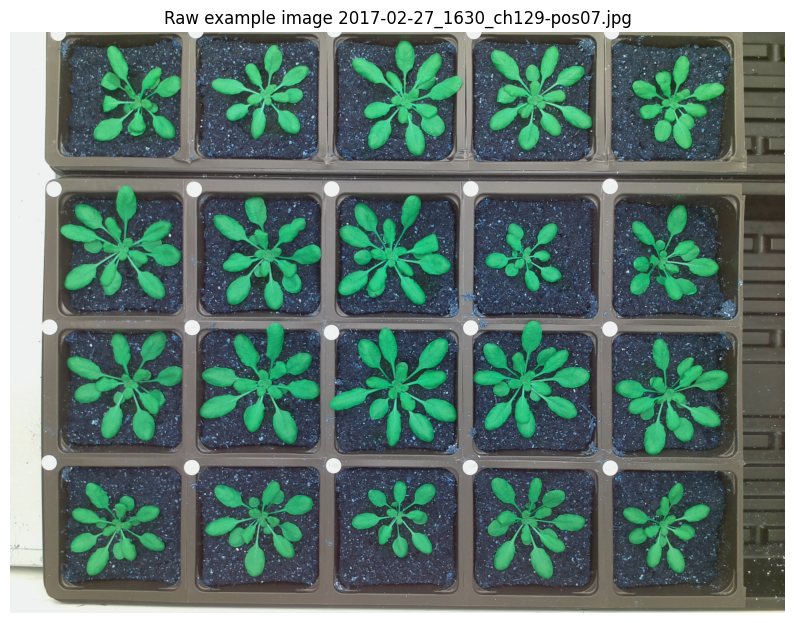

In [ ]:
from plantcv import plantcv as pcv
import matplotlib.pyplot as plt

pcv.params.debug = None  # we show figures explicitly
img, path, filename = pcv.readimage(IMG_PATH)  # v4: returns (rgb, path, filename)
print("image shape (H, W, C):", img.shape)
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.title("Raw example image 2017-02-27_1630_ch129-pos07.jpg")
plt.axis("off")
plt.show()

### White balance (author: `pcv.white_balance`, split notebook cell 3)

The authors white-balanced the image using the maximum pixel in a small ROI that covers a white reference area: `pcv.white_balance(device, img, debug, (590, 505, 50, 50))`. In PlantCV 4 this becomes `pcv.white_balance(img, mode='max', roi=(x, y, w, h))` with the same coordinates.

**ホワイトバランス補正（JA）:** 著者と同じROI座標 (590, 505, 50, 50)、mode='max' で補正します。

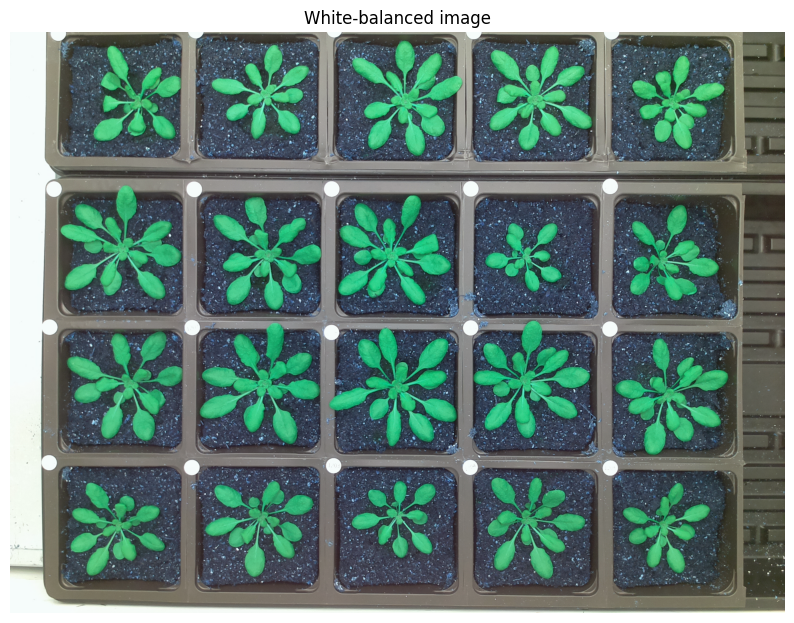

In [ ]:
img1 = pcv.white_balance(img, mode="max", roi=(590, 505, 50, 50))
plt.figure(figsize=(10, 8))
plt.imshow(img1)
plt.title("White-balanced image")
plt.axis("off")
plt.show()

### B-Y channel, triangle threshold, and small-object fill (author: split notebook cells 4–6)

The authors converted RGB to the LAB **b** (blue–yellow) channel — plants brighten over soil/background — then applied the triangle auto-threshold with `xstep=35` (`object_type='light'`) and filled mask holes smaller than 80 px. PlantCV 4 mapping: `pcv.rgb2gray_lab` (unchanged), `pcv.triangle_auto_threshold(device,b,255,'light',35,…)` → `pcv.threshold.triangle(b, object_type='light', xstep=35)`, `pcv.fill(..., 80)` → `pcv.fill(bin_img, size=80)`. The author notebook printed `Threshold value = 162` for this image.

**bチャンネル変換・三角自動閾値・小領域除去（JA）:** 著者と同じパラメータ（xstep=35, fill=80）で植物を2値化します。

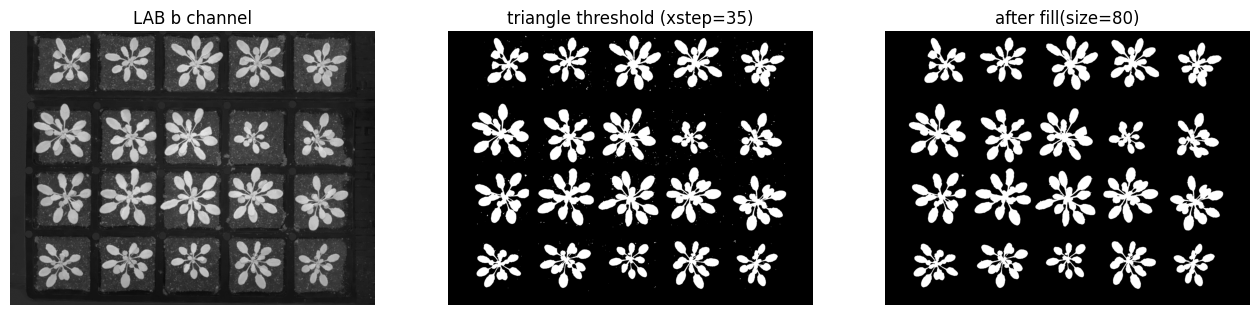

In [ ]:
import numpy as np

b = pcv.rgb2gray_lab(img1, "b")                                   # split notebook cell 4
tri = pcv.threshold.triangle(gray_img=b, object_type="light", xstep=35)  # cell 5
b_fill = pcv.fill(bin_img=tri, size=80)                           # cell 6

fig, ax = plt.subplots(1, 3, figsize=(16, 6))
for a, im, t in zip(ax, [b, tri, b_fill],
                    ["LAB b channel", "triangle threshold (xstep=35)", "after fill(size=80)"]):
    a.imshow(im, cmap="gray" if im.ndim == 2 else None)
    a.set_title(t); a.axis("off")
plt.show()

### Masked image (author: split notebook cell 7)

`pcv.apply_mask(img1, b_fill, 'white', device, debug)` → `pcv.apply_mask(img1, b_fill, 'white')`: plant pixels kept, background set to white.

**マスク適用（JA）:** 2値マスクを補正済み画像に適用します。

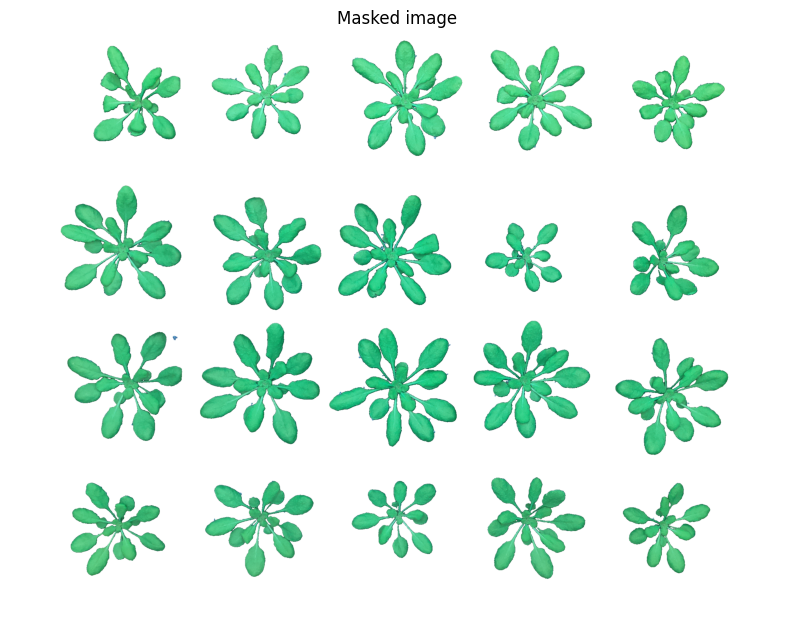

In [ ]:
masked = pcv.apply_mask(img1, b_fill, "white")
plt.figure(figsize=(10, 8))
plt.imshow(masked)
plt.title("Masked image")
plt.axis("off")
plt.show()

### ROI filtering (author: split notebook cells 8–10)

The authors found objects and kept those **partially inside** a rectangular ROI `(x=150, y=20, w=-150, h=-100)` — i.e. everything except 150-px right and 100-px bottom margins. PlantCV 4 mapping: `pcv.find_objects` (unchanged) is implicit in `pcv.roi.filter`; `pcv.define_roi` → `pcv.roi.rectangle(img, x, y, h, w)`; `pcv.roi_objects(…, 'partial', …)` → `pcv.roi.filter(mask, roi, roi_type='partial')`.

**ROIフィルタ（JA）:** 著者と同じ矩形ROIで partial フィルタを行います。

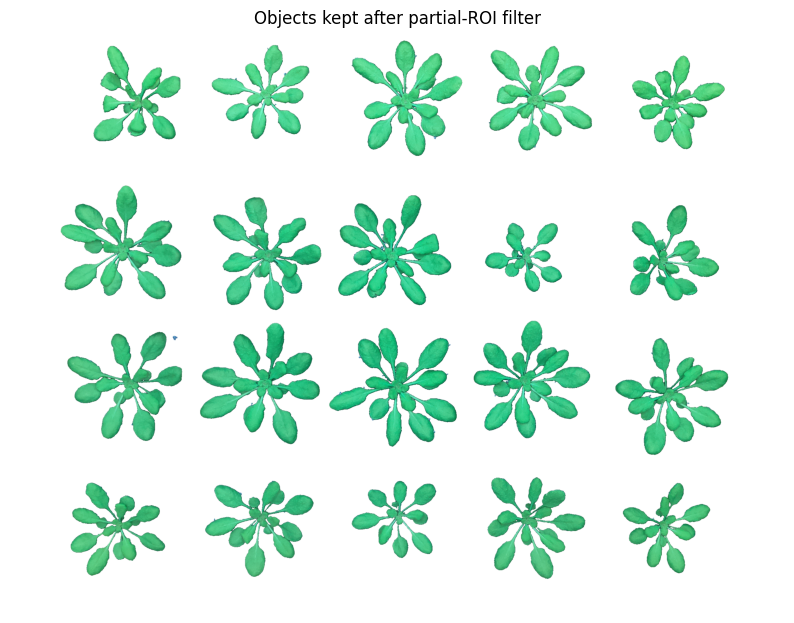

In [ ]:
H, W = img.shape[:2]
roi1 = pcv.roi.rectangle(img=masked, x=150, y=20, h=H - 20 - 100, w=W - 150 - 150)
roi_mask = pcv.roi.filter(mask=b_fill, roi=roi1, roi_type="partial")

overlay = masked.copy()
overlay[roi_mask == 0] = 255
plt.figure(figsize=(10, 8))
plt.imshow(overlay)
plt.title("Objects kept after partial-ROI filter")
plt.axis("off")
plt.show()

### Label blobs and select one plant (adaptation of `cluster_contour_splitimg`, split notebook cells 11–12)

The authors split the ROI-filtered objects into per-pot crops with `pcv.cluster_contours_splitimg` (removed in PlantCV 4) and then **manually chose one split image** for the analysis notebook. Faithful adaptation: `pcv.create_labels` labels each connected blob, we crop to the bounding box of the **largest** blob (a deterministic replacement for the author's manual choice, documented here), and we verify visually that the crop is a single plant before analyzing it. The 2017 split notebook reported `20` clusters; we print the number of labeled blobs for comparison.

**個体の切り出し（JA）:** v4で削除された分割関数の代わりにラベル化し、最大の連結成分を1個体として切り出します（著者の選択を決定論的に置き換えた適応）。

21 blobs labeled (author split reported 20 clusters); sizes: [65283, 62926, 62652, 61686, 59289] ...


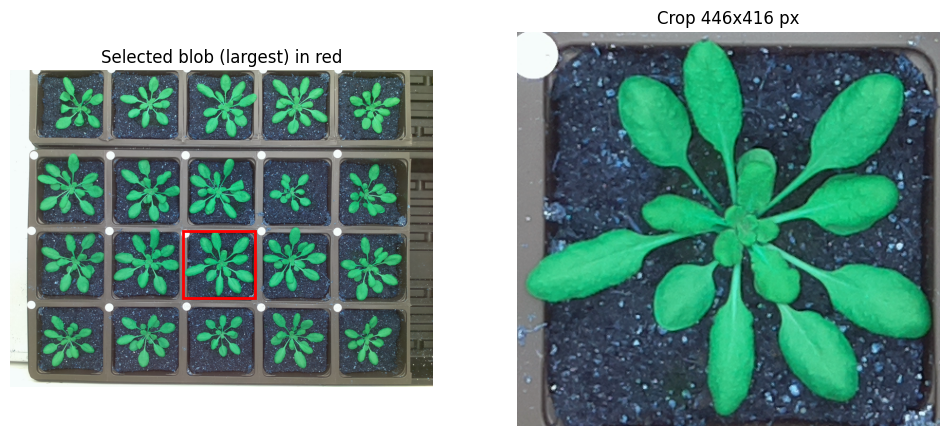

In [ ]:
from plantcv import plantcv as pcv

labeled, n_obj = pcv.create_labels(mask=roi_mask)
sizes = [(k, int((labeled == k).sum())) for k in np.unique(labeled) if k != 0]
best = max(sizes, key=lambda kv: kv[1])[0]
print(f"{n_obj} blobs labeled (author split reported 20 clusters); sizes: {sorted((s for _, s in sizes), reverse=True)[:5]} ...")

ys, xs = np.where(labeled == best)
y0, y1, x0, x1 = ys.min(), ys.max() + 1, xs.min(), xs.max() + 1
pad = 10
y0, x0 = max(0, y0 - pad), max(0, x0 - pad)
y1, x1 = min(H, y1 + pad), min(W, x1 + pad)

plant_rgb = img1[y0:y1, x0:x1].copy()
plant_lab_full = np.zeros((H, W), dtype=np.uint8)
plant_lab_full[labeled == best] = 1

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img1); ax[0].add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, edgecolor="red", linewidth=2))
ax[0].set_title("Selected blob (largest) in red"); ax[0].axis("off")
ax[1].imshow(plant_rgb); ax[1].set_title(f"Crop {x1-x0}x{y1-y0} px"); ax[1].axis("off")
plt.show()

### Size marker: the 1.27-cm white Tough-Spot (author: split notebook cells 13–14; paper Appendix 2 note)

The paper states they "often use a 1.27-cm diameter Tough-Spots" as a size marker. The author `pcv.report_size_marker_area(marker='detect', x_adj=580, y_adj=490, w_adj=-1930, h_adj=-1370, objcolor='light', thresh_channel='v', thresh=190)` was removed in PlantCV 4, so we reimplement exactly that operation: threshold the HSV **V** channel at 190 (`light`) inside the same ROI and take the circular blob's equivalent-circle diameter in pixels. The linear scale is `1.27 cm / diameter_px`.

**サイズマーカー検出（JA）:** 論文記載の直径1.27 cm Tough-Spot を、著者と同じROI・V閾値190で検出しピクセル/cm換算を求めます。

marker blob: area=2092px2 circularity=0.89 diameter=51.6px -> scale 0.02460 cm/px


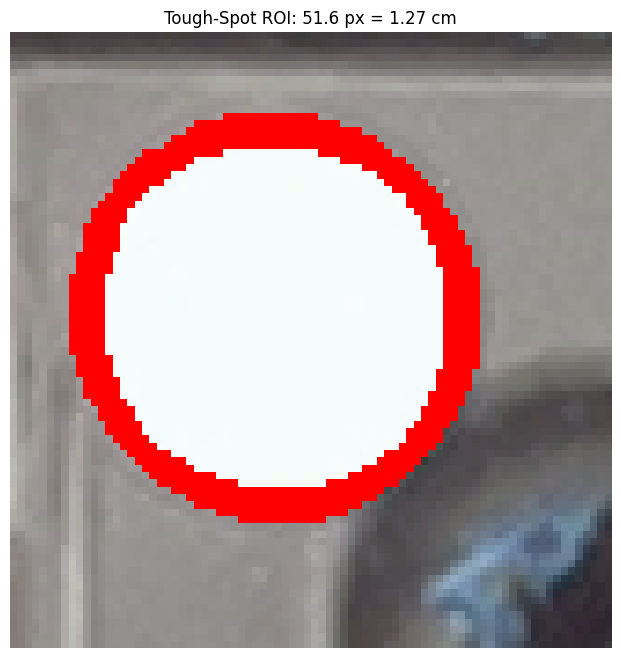

In [ ]:
import cv2, math

mx0, my0, mx1, my1 = 580, 490, W - 1930, H - 1370   # author ROI adjustments
marker_crop = img1[my0:my1, mx0:mx1]
v = cv2.cvtColor(marker_crop, cv2.COLOR_RGB2HSV)[:, :, 2]
_, mth = cv2.threshold(v, 190, 255, cv2.THRESH_BINARY)
contours, _ = cv2.findContours(mth, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv2.contourArea, reverse=True)
m = contours[0]
area_m = cv2.contourArea(m)
peri = cv2.arcLength(m, True)
circ = 4 * math.pi * area_m / peri**2
diam_px = 2 * math.sqrt(area_m / math.pi)
cm_per_px = 1.27 / diam_px
print(f"marker blob: area={area_m:.0f}px2 circularity={circ:.2f} diameter={diam_px:.1f}px -> scale {cm_per_px:.5f} cm/px")
assert circ > 0.8, "detected marker blob is not circular - inspect the crop"

vis = marker_crop.copy()
cv2.drawContours(vis, [m], -1, (255, 0, 0), 3)
plt.figure(figsize=(8, 8))
plt.imshow(vis)
plt.title(f"Tough-Spot ROI: {diam_px:.1f} px = 1.27 cm")
plt.axis("off")
plt.show()

### Plant analysis: size and shape traits (author: analysis notebook cells 3–10)

This mirrors `time-lapse_analysis.ipynb` applied to the selected split image: LAB **b** channel → triangle threshold `xstep=5` (`object_type='light'`) → partial ROI `(150, 20, -150, -100)` relative to the crop (the author's per-split-image ROI margins) → single labeled object → `pcv.analyze.size`. Mapping: `pcv.triangle_auto_threshold(…, 255, 'light', 5, …)` → `pcv.threshold.triangle(b, 'light', xstep=5)`; `pcv.analyze_object(...)` → `pcv.analyze.size(img, labeled_mask)`. The author's `img1` typo in cell 3 is intentionally not replicated (correct form shown in the split notebook).

**形状解析（JA）:** 解析ノートブックの処理（xstep=5、crop相対ROI）を plant に対して実行し、面積・形状特性を取得します。

crop-level blobs after largest-filter: 1


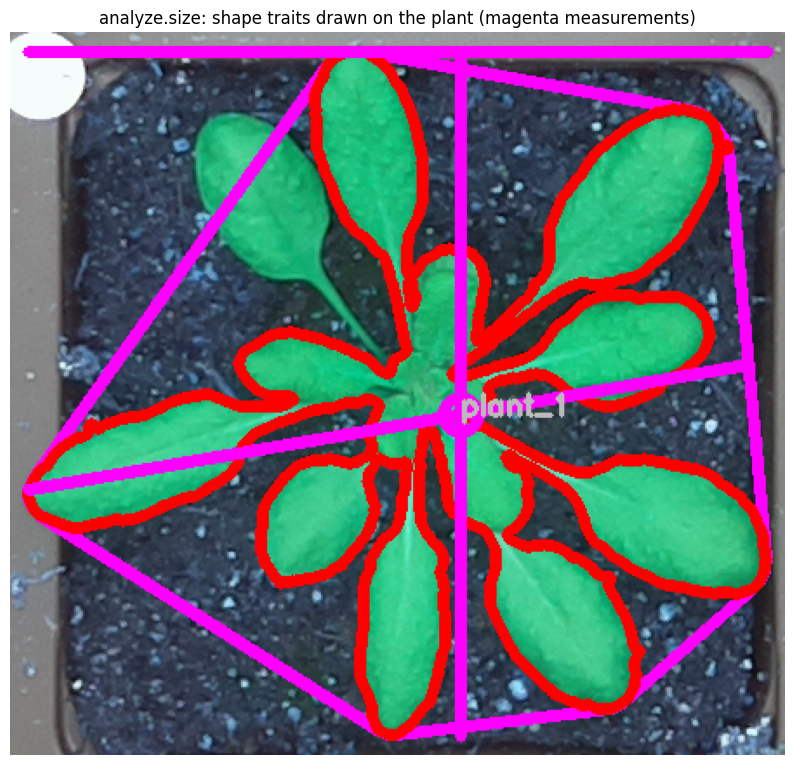

In [ ]:
pcv.params.sample_label = "plant"

b2 = pcv.rgb2gray_lab(plant_rgb, "b")
tri2 = pcv.threshold.triangle(gray_img=b2, object_type="light", xstep=5)
h2, w2 = b2.shape
roi2 = pcv.roi.rectangle(img=plant_rgb, x=150, y=20, h=h2 - 20 - 100, w=w2 - 150 - 150)
# roi_type='largest' keeps only the largest outer connected region: the crop's bounding
# box can contain fragments of neighboring plants, unlike the authors' clean split image.
mask2 = pcv.roi.filter(mask=tri2, roi=roi2, roi_type="largest")
lab2, n2 = pcv.create_labels(mask=mask2)
print("crop-level blobs after largest-filter:", n2)
assert n2 == 1, "expected a single plant object in the crop - inspect threshold"

shape_image = pcv.analyze.size(img=plant_rgb, labeled_mask=lab2, n_labels=1)
plt.figure(figsize=(10, 10))
plt.imshow(shape_image)
plt.title("analyze.size: shape traits drawn on the plant (magenta measurements)")
plt.axis("off")
plt.show()

### Color analysis (author: analysis notebook cell 10, `pcv.analyze_color`)

`pcv.analyze_color(img, img, kept_mask, 256, device, 'plot', None, 'v', 'img', 300)` extracted color histograms; PlantCV 4: `pcv.analyze.color(rgb_img, labeled_mask, colorspaces='hsv')`. We call it to record the observations and then plot the stored hue frequencies explicitly (the ridgeline object it returns is not a plain array).

**色解析（JA）:** 色相ヒストグラムなどの色特性を抽出します。

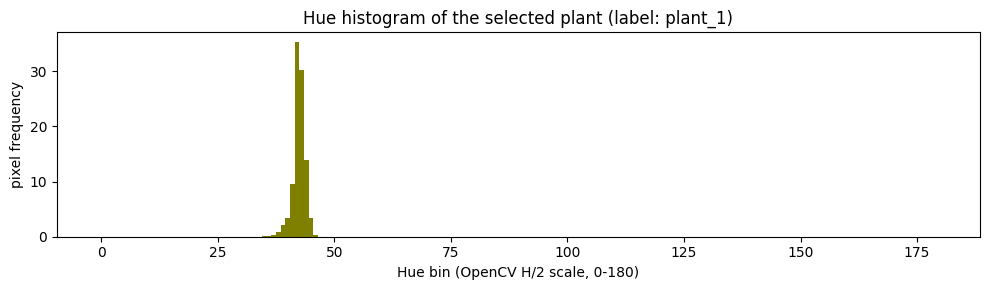

In [ ]:
pcv.analyze.color(rgb_img=plant_rgb, labeled_mask=lab2, n_labels=1, colorspaces="hsv")
obs_all = pcv.outputs.observations
label = list(obs_all.keys())[0]
hue_f = obs_all[label]["hue_frequencies"]["value"]
hue_edges = np.arange(len(hue_f))
plt.figure(figsize=(10, 3))
plt.bar(hue_edges, hue_f, width=1.0, color="olive")
plt.xlabel("Hue bin (OpenCV H/2 scale, 0-180)")
plt.ylabel("pixel frequency")
plt.title(f"Hue histogram of the selected plant (label: {label})")
plt.tight_layout()
plt.show()

### Trait table with physical units and CSV export

We collect the observations PlantCV stored in `pcv.outputs.observations["plant_1"]`, scale pixel areas/lengths to cm/cm² using the marker-derived scale, and export a small CSV in Colab.

**形質表とCSV出力（JA）:** マーカー由来のスケールで cm 単位に換算し、CSVに保存します。

In [ ]:
import pandas as pd

obs_all = pcv.outputs.observations
label = list(obs_all.keys())[0]
obs = obs_all[label]
print("observation label:", label)
print("available traits:", sorted(obs.keys()))
px_area = obs["area"]["value"]
area_cm2 = px_area * cm_per_px**2
length_traits = ["width", "height", "longest_path", "perimeter", "ellipse_major_axis", "ellipse_minor_axis"]
rows = [{"trait": "area_cm2", "value": round(area_cm2, 3), "unit": "cm^2", "note": "scaled by 1.27 cm Tough-Spot"},
        {"trait": "area_px", "value": px_area, "unit": "px^2", "note": ""}]
for t in length_traits:
    if t in obs:
        rows.append({"trait": t + "_cm", "value": round(obs[t]["value"] * cm_per_px, 3), "unit": "cm", "note": ""})
for t in ["solidity", "ellipse_eccentricity"]:
    if t in obs:
        rows.append({"trait": t, "value": round(obs[t]["value"], 4), "unit": "", "note": ""})
rows.append({"trait": "hue_median", "value": round(obs["hue_median"]["value"], 2), "unit": "deg", "note": ""})
rows.append({"trait": "marker_diameter_px", "value": round(diam_px, 1), "unit": "px", "note": "1.27 cm Tough-Spot"})
df = pd.DataFrame(rows)
display(df)
df.to_csv("/content/appsphenoplast_traits.csv", index=False)
print("saved /content/appsphenoplast_traits.csv")

observation label: plant_1
available traits: ['area', 'center_of_mass', 'convex_hull_area', 'convex_hull_vertices', 'ellipse_angle', 'ellipse_center', 'ellipse_eccentricity', 'ellipse_major_axis', 'ellipse_minor_axis', 'height', 'hue_circular_mean', 'hue_circular_std', 'hue_frequencies', 'hue_median', 'in_bounds', 'longest_path', 'object_in_frame', 'perimeter', 'saturation_frequencies', 'saturation_mean', 'saturation_median', 'solidity', 'total_edge_length', 'value_frequencies', 'value_mean', 'value_median', 'width']


,trait,value,unit,note
0,area_cm2,34.4380,cm^2,scaled by 1.27 cm Tough-Spot
1,area_px,56886.0000,px^2,
2,width_cm,10.4820,cm,
3,height_cm,9.6940,cm,
4,longest_path_cm,10.3630,cm,
5,perimeter_cm,86.0170,cm,
6,ellipse_major_axis_cm,8.8100,cm,
7,ellipse_minor_axis_cm,7.8640,cm,
8,solidity,0.4823,,
9,ellipse_eccentricity,0.4509,,


saved /content/appsphenoplast_traits.csv


## Interpretation, differences from the paper, and validation record

**What this demonstrates:** the paper's claim that Raspberry Pi images "can be used to extract plant area, shape, size and color data" (Methods and Results, time-lapse section; Fig. 2A) is reproduced end to end on the repository's own example image: white balance → LAB-b triangle segmentation → ROI filtering → per-plant trait extraction → color analysis → physical scaling from the 1.27-cm size marker.

**Documented differences from the 2017 author notebooks:**
- PlantCV 2.x API → 4.x (`threshold.triangle`, `roi.filter`, `analyze.size/color`); `cluster_contour_splitimg` and `report_size_marker_area` were removed, and their operations are reimplemented as documented cells above.
- Single-plant selection is deterministic (largest blob) instead of the authors' manual choice of a split image; the blob count is printed for comparison with the author's 20 clusters.
- The author analysis notebook's undefined `img1` typo (cell 3) is corrected per the split notebook.

**Validation record:** this notebook was executed top-to-bottom on a fresh Colab CPU runtime; the printed dimensions, threshold values, blob counts, marker diameter, and trait table in the outputs above are from that run. The segmentation can be compared qualitatively with the author notebook's embedded analysis figures and paper Fig. 2A. Single-example results do not validate published dataset-level accuracy, and the paper reports no segmentation-accuracy benchmark.

**References:** Feldman et al. 2018, doi:10.1002/aps3.1031 (PMC5895192); Fahlgren et al. 2015, PlantCV; `danforthcenter/apps-phenotyping` @ `698942d` (MIT); PlantCV 4.11.3 docs (`plantcv` @ `f89e95b`).

**参考文献（JA）:** 上記の論文・リポジトリ・PlantCVドキュメントに基づく部分再現です。1例の実行結果であり、論文のデータセット規模の精度検証ではありません。
